# LSTM

## Imports

In [ ]:
import time
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    SpatialDropout1D,
    Input
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ModelCheckpoint,
    ReduceLROnPlateau
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [ ]:
x_train = joblib.load("/content/x_train.pkl")
x_test = joblib.load("/content/x_test.pkl")

y_train = joblib.load("/content/y_train.pkl")
y_test = joblib.load("/content/y_test.pkl")

In [ ]:
print("x_train:", x_train.shape)
print("x_test :", x_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

x_train: (1274150,)
x_test : (318538,)
y_train: (1274150,)
y_test : (318538,)


In [ ]:
print("Train Missing:", x_train.isna().sum())
print("Test Missing :", x_test.isna().sum())

Train Missing: 0
Test Missing : 0


Tokenizer

In [ ]:
VOCAB_SIZE = 50000

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>"
)

In [ ]:
tokenizer.fit_on_texts(x_train)

In [ ]:
joblib.dump(tokenizer, "tokenizer.pkl")

['tokenizer.pkl']

Text ---> Sequences

In [ ]:
x_tr_seq = tokenizer.texts_to_sequences(x_train)
x_te_seq = tokenizer.texts_to_sequences(x_test)

In [ ]:
seq_len = [len(seq) for seq in x_tr_seq]

print("Maximum Length :", max(seq_len))
print("Minimum Length :", min(seq_len))
print("Average Length :", np.mean(seq_len))
print("Median Length  :", np.median(seq_len))
print("95th Percentile:", np.percentile(seq_len, 95))

Maximum Length : 56
Minimum Length : 1
Average Length : 7.173818624180827
Median Length  : 7.0
95th Percentile: 14.0


Pad the Seqences

In [ ]:
MAX_LENGTH = 20

x_tr_pad = pad_sequences(
    x_tr_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

x_te_pad = pad_sequences(
    x_te_seq,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

In [ ]:
print(x_tr_pad.shape)
print(x_te_pad.shape)

(1274150, 20)
(318538, 20)


## Model

In [ ]:
VOCAB_SIZE = 50000
EMBEDDING_DIM = 128

model = Sequential([
    Input(
        shape=(MAX_LENGTH,)
    ),

    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
    ),
    SpatialDropout1D(0.2),

    LSTM(
        128,
        dropout=0.2,
        recurrent_dropout=0.2
    ),

    Dense(
        64,
        activation="relu"
    ),
    Dropout(0.3),
    Dense(
        1,
        activation="sigmoid"
    )
])

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 20, 128)        │     6,400,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 20, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,539,905 (24.95 MB)

 Trainable params: 6,539,905 (24.95 MB)

 Non-trainable params: 0 (0.00 B)

Compile

In [ ]:
model.compile(
    optimizer='adam',
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True,
    verbose=1
)
checkpoints = ModelCheckpoint(
    "best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

Training

In [ ]:
from sklearn.utils import validation
start = time.time()

history = model.fit(
    x_tr_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=512,
    callbacks=[
        early_stop,
        checkpoints,
        reduce_lr
    ],
    verbose=1
)
end = time.time()
print(f"Training Time: {(end-start)/60:.2f} Minutes")

Epoch 1/10
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - accuracy: 0.7399 - loss: 0.5163 - precision: 0.7453 - recall: 0.7173
Epoch 1: val_accuracy improved from None to 0.78913, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 179s 86ms/step - accuracy: 0.7698 - loss: 0.4823 - precision: 0.7717 - recall: 0.7663 - val_accuracy: 0.7891 - val_loss: 0.4493 - val_precision: 0.7778 - val_recall: 0.8099 - learning_rate: 0.0010
Epoch 2/10
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7967 - loss: 0.4381 - precision: 0.7965 - recall: 0.7969
Epoch 2: val_accuracy improved from 0.78913 to 0.79325, saving model to best_model.keras

Epoch 2: finished saving model to best_model.keras
1991/1991 ━━━━━━━━━━━━━━━━━━━━ 195s 84ms/step - accuracy: 0.7964 - loss: 0.4384 - precision: 0.7951 - recall: 0.7987 - val_accuracy: 0.7933 - val_loss: 0.4453 - val_precision: 0.8063 - val_recall: 0.7723 - learning_rate: 0.0010
Epoch 3/10
19

In [ ]:
y_prob = model.predict(x_te_pad)
y_pred = (y_prob > 0.5).astype(int)

9955/9955 ━━━━━━━━━━━━━━━━━━━━ 153s 15ms/step


In [ ]:
y_pred = y_pred.ravel()

In [ ]:
print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score : {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC  : {roc_auc_score(y_test, y_prob):.4f}")

Accuracy : 0.7920
Precision: 0.8045
Recall   : 0.7715
F1 Score : 0.7877
ROC AUC  : 0.8753


In [ ]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.78      0.81      0.80    159267
           1       0.80      0.77      0.79    159271

    accuracy                           0.79    318538
   macro avg       0.79      0.79      0.79    318538
weighted avg       0.79      0.79      0.79    318538



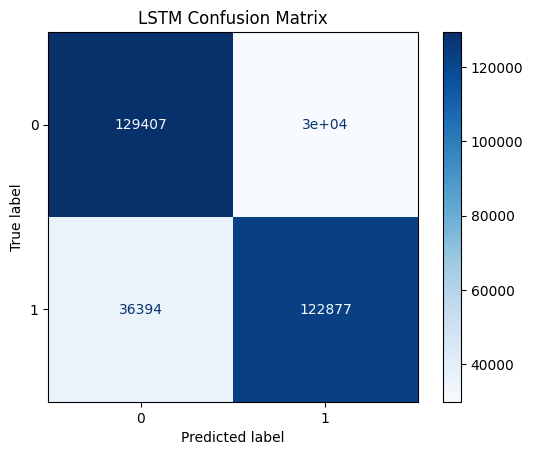

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

plt.title("LSTM Confusion Matrix")
plt.show()

In [ ]:
model.save("lstm_sentiment.keras")

In [ ]:
model.save("best_lstm.keras")
joblib.dump(history.history, "history.pkl")

['history.pkl']